<a href="https://colab.research.google.com/github/yakdudi12/IID/blob/main/TP3/TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 - Análisis Multivariante del Ecosistema Global de Noticias

## Introducción

En el TP1 procesamos el flujo de datos de GDELT 2.0. En el TP2 diseñamos un Data Warehouse para responder preguntas del negocio periodístico. En este TP3 extendemos ese diseño y aplicamos análisis multivariante para caracterizar el ecosistema global de noticias.

GDELT es ruidoso, disperso y de alta dimensionalidad. Eso condiciona cada decisión metodológica que tomo a continuación.

Las cuatro preguntas que guían el análisis:

1. ¿Cómo se caracterizan simultáneamente los eventos mediante sus vectores de medias?
2. ¿Qué perfiles de eventos son más similares y disímiles al comparar distancias?
3. ¿Existen asociaciones entre las variables de los eventos?
4. ¿Cuántas componentes principales resumen la varianza total y cómo se interpretan?

Documento cada decisión a medida que avanzo.

# Actividad 1: Ingesta de datos

## Extensión del Data Warehouse del TP2

El DW del TP2 agrupaba eventos por tiempo, tipo de evento y geografía (`dw_tiempo`, `dw_evento`, `dw_geo`). La consigna del TP3 pide extender ese diseño para incluir actores 1 y 2, tipo de interacción, región, tono e impacto Goldstein.

Agrego una cuarta tabla al DW: `dw_evento_extendido`, que agrupa por la combinación de actor1, actor2, tipo de evento y región, y agrega métricas agregadas de tono, Goldstein y menciones. Esta tabla es la que efectivamente responde a la consigna de extensión del DW.

Además, para el análisis multivariante necesito conservar las variables a nivel de evento individual. Por eso, en la misma pasada de descarga, genero también una muestra analítica del 10% de los registros que uso como tabla de hechos para el ACP.

Variables que incorporo al diseño extendido:

- **Actores**: Actor1Code, Actor1CountryCode, Actor1Type1Code, Actor2Code, Actor2CountryCode, Actor2Type1Code.
- **Tipo de interacción**: EventRootCode, QuadClass.
- **Región**: ActionGeo_CountryCode.
- **Tono**: AvgTone.
- **Impacto**: GoldsteinScale.
- **Cobertura**: NumMentions, NumSources, NumArticles.

In [ ]:
import os
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

DATA = Path.cwd() / "data_gdelt"
DATA.mkdir(exist_ok=True)

#Prompt Usado en Gemini:
Necesito que me ayudes a reimplementar mi data warehouse que hice sobre unos datos. La idea es hacer esas consultas y guardar los resumenes (eso seria un data warehouse). Por ahora solo ayudame a darle viabilidad a las consultas. Te suministrare ambos codigos para que veas mi intencion:

#Actividad 1: Ingesta de Datos

In [ ]:
COLUMNS = [
    "GlobalEventID", "Day", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles",
    "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
    "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
    "ActionGeo_Long", "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL"
]

In [ ]:
url_master = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"
master = pd.read_csv(url_master, sep=" ", header=None, names=["size", "hash", "url"], low_memory=False)

# Rango ampliado a 30 días
fecha_ini = "20260810"
fecha_fin = "20260909"

urls = master[
    master["url"].str.endswith(".export.CSV.zip") &
    master["url"].str.extract(r"(\d{8})")[0].between(fecha_ini, fecha_fin)
]["url"].tolist()

print(f"Archivos a descargar y procesar: {len(urls)}")

Archivos a descargar y procesar: 2976


## Definición explícita de variables para el análisis

Para evitar la contaminación del ACP por variables que no son categóricas reales (coordenadas, códigos administrativos, FeatureIDs), defino explícitamente qué variables entran al modelo.

**Continuas (5):** GoldsteinScale, AvgTone, NumMentions, NumSources, NumArticles.

**Categóricas (9):**
- Actores 1 y 2: Actor1Code, Actor1CountryCode, Actor1Type1Code, Actor2Code, Actor2CountryCode, Actor2Type1Code.
- Tipo de interacción: EventRootCode, QuadClass.
- Región: ActionGeo_CountryCode.

Excluyo EventCode y EventBaseCode porque son refinamientos de EventRootCode. Sus distribuciones en la cola larga terminan siendo idénticas tras la reducción de cardinalidad, así que no aportan información independiente.

Quedan ~40–60 columnas efectivas tras el one-hot, en lugar de 131.

In [ ]:
cols_continuas = ["GoldsteinScale", "AvgTone", "NumMentions", "NumSources", "NumArticles"]
cols_categoricas = [
    "Actor1Code", "Actor1CountryCode", "Actor1Type1Code",
    "Actor2Code", "Actor2CountryCode", "Actor2Type1Code",
    "EventRootCode", "QuadClass", "ActionGeo_CountryCode",
]

def procesar_archivo(url):
    """Descarga, resume para el DW y devuelve muestra analítica."""
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        df = pd.read_csv(
            BytesIO(r.content), sep="\t", header=None, names=COLUMNS,
            compression="zip", low_memory=False, quoting=3
        )

        # --- Resúmenes del DW (originales) ---
        res_tiempo = df.groupby("MonthYear").size().reset_index(name="n")
        res_evento = df.groupby(["EventRootCode", "Year"]).size().reset_index(name="n")
        res_geo = df.groupby("ActionGeo_CountryCode").size().reset_index(name="n")

        # --- NUEVO: tabla extendida del DW (corrección 9) ---
        res_ext = (
            df.groupby(["Actor1CountryCode", "Actor2CountryCode",
                        "EventRootCode", "QuadClass", "ActionGeo_CountryCode"])
              .agg(n=("GlobalEventID", "size"),
                   tono=("AvgTone", "mean"),
                   goldstein=("GoldsteinScale", "mean"),
                   menciones=("NumMentions", "sum"))
              .reset_index()
        )

        # --- Muestra analítica para el ACP ---
        df = df[cols_continuas + cols_categoricas].copy()
        df = df.dropna(subset=["GoldsteinScale", "AvgTone"])
        # log1p a los conteos (corrección 6)
        df[["NumMentions", "NumSources", "NumArticles"]] = np.log1p(
            df[["NumMentions", "NumSources", "NumArticles"]].astype(float)
        )
        muestra = df.sample(frac=0.10, random_state=42)

        return {
            "tiempo": res_tiempo,
            "evento": res_evento,
            "geo": res_geo,
            "ext": res_ext,
            "muestra": muestra,
        }
    except Exception as e:
        print(f"Error procesando {url}: {e}")
        return None

In [ ]:
with ThreadPoolExecutor(max_workers=10) as ex:
    resultados = [r for r in ex.map(procesar_archivo, urls) if r is not None]

print(f"Archivos procesados exitosamente: {len(resultados)}")

Archivos procesados exitosamente: 2976


In [ ]:
resumenes_tiempo = [r["tiempo"] for r in resultados]
resumenes_evento = [r["evento"] for r in resultados]
resumenes_geo    = [r["geo"]    for r in resultados]
resumenes_ext    = [r["ext"]    for r in resultados]
muestras         = [r["muestra"] for r in resultados]

dw_tiempo = pd.concat(resumenes_tiempo).groupby("MonthYear")["n"].sum().reset_index()
dw_evento = pd.concat(resumenes_evento).groupby(["EventRootCode", "Year"])["n"].sum().reset_index()
dw_geo    = pd.concat(resumenes_geo).groupby("ActionGeo_CountryCode")["n"].sum().reset_index()

# Tabla extendida: promedios ponderados por n (no se promedian promedios)
claves = ["Actor1CountryCode", "Actor2CountryCode", "EventRootCode", "QuadClass", "ActionGeo_CountryCode"]
ext = pd.concat(resumenes_ext, ignore_index=True)
ext["tono_x_n"] = ext["tono"] * ext["n"]
ext["gold_x_n"] = ext["goldstein"] * ext["n"]

dw_extendido = (
    ext.groupby(claves, dropna=False)
       .agg(n=("n", "sum"), tono_x_n=("tono_x_n", "sum"),
            gold_x_n=("gold_x_n", "sum"), menciones_total=("menciones", "sum"))
       .reset_index()
)
dw_extendido["tono_pond"] = dw_extendido["tono_x_n"] / dw_extendido["n"]
dw_extendido["goldstein_pond"] = dw_extendido["gold_x_n"] / dw_extendido["n"]
dw_extendido = dw_extendido.drop(columns=["tono_x_n", "gold_x_n"])

dw_tiempo.to_csv(DATA / "dw_tiempo.csv", index=False)
dw_evento.to_csv(DATA / "dw_evento.csv", index=False)
dw_geo.to_csv(DATA / "dw_geo.csv", index=False)
dw_extendido.to_csv(DATA / "dw_extendido.csv", index=False)

print("Data Warehouse extendido guardado.")
print(f"dw_extendido: {dw_extendido.shape}")

Data Warehouse extendido guardado.
dw_extendido: (120793, 9)


In [ ]:
df_analitico = pd.concat(muestras, ignore_index=True).reset_index(drop=True)

# Guardamos el país original SIN reducir (corrección 3)
pais_raw = df_analitico["ActionGeo_CountryCode"].astype(str).copy()

# Reducción de cardinalidad: umbral 5% -> OTHER
for col in cols_categoricas:
    df_analitico[col] = df_analitico[col].astype(str)
    freq = df_analitico[col].value_counts(normalize=True)
    df_analitico[col] = df_analitico[col].where(
        df_analitico[col].isin(freq[freq >= 0.05].index), "OTHER"
    )

# One-hot encoding
matriz_datos = pd.get_dummies(df_analitico, columns=cols_categoricas, dtype=int)

print(f"Dimensiones df_analitico: {df_analitico.shape}")
print(f"Dimensiones matriz_datos: {matriz_datos.shape}")

Dimensiones df_analitico: (296204, 14)
Dimensiones matriz_datos: (296204, 41)


### Resultado de la construcción de la matriz

Tras la reducción de cardinalidad y el one-hot, la matriz quedó con **296.204 filas y 41 columnas**. La cantidad de columnas bajó de 131 (versión anterior) a 41, dentro del rango 40–60 esperado.

Algunas observaciones:

- Tras la reducción de cardinalidad (umbral 5%), `ActionGeo_CountryCode` conserva solo India (IN), Estados Unidos (US) y Reino Unido (UK), más `OTHER`. Para el análisis por país uso aparte los 10 países más frecuentes, tomados de `pais_raw` (sin reducir).
- Ya no hay columnas constantes como `ActionGeo_Lat_OTHER` o `ActionGeo_FeatureID_OTHER`, que en la versión anterior tenían media 1.0 y contaminaban el ACP.
- Tampoco hay pares espejo `_OTHER`/`_nan` provenientes de coordenadas, FeatureID o ADM, porque esas columnas quedaron fuera del modelo.
- Los eventos sin país asignado (`nan`) tienen frecuencia menor al 5%, por lo que dentro de `matriz_datos` quedan en `OTHER`. Solo existen como grupo propio en `pais_raw`, que uso para agrupar en la Actividad 2.

La matriz está lista para el análisis multivariante.

# Actividad 2: Descripción multivariante

## Escalado previo

Antes de cualquier cálculo de distancias o medias por país, escalo la matriz. Razón: `NumMentions`, `NumSources` y `NumArticles` tienen varianza mucho mayor que `AvgTone`, `GoldsteinScale` o las dummies. Si no escalo, dominan por peso absoluto y todo el análisis queda sesgado.

Uso `StandardScaler` (media 0, desvío 1), que es equivalente a hacer el ACP sobre la matriz de correlaciones en lugar de la de covarianzas.

**Sobre escalar dummies:** escalar una dummy con 5% de frecuencia le da el mismo peso que a una variable continua, lo que amplifica categorías raras. Es la contrapartida de tratar todas las variables en pie de igualdad. Es el trade-off que elijo: prefiero no asumir a priori qué variables son más importantes, y documento esta limitación.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
matriz_escalada = scaler.fit_transform(matriz_datos)

X = pd.DataFrame(matriz_escalada, columns=matriz_datos.columns, index=matriz_datos.index)
print(f"Dimensiones matriz escalada: {X.shape}")

Dimensiones matriz escalada: (296204, 41)


In [ ]:
PAISES = {
    "US": "EE.UU.", "IN": "India", "UK": "Reino Unido", "NI": "Nigeria",
    "IS": "Israel", "CA": "Canadá", "IR": "Irán", "CH": "China",
    "AS": "Australia", "nan": "Sin país asignado",
}

In [ ]:
# Excluyo dummies de país para no contaminar la distancia (corrección 3)
X_sin_pais = X[[c for c in X.columns if not c.startswith("ActionGeo_CountryCode_")]]

top_paises = pais_raw.value_counts().head(10).index

vt_mean_global  = X_sin_pais.mean()
vt_mean_country = X_sin_pais.groupby(pais_raw).mean().loc[top_paises]

print("Vector de medias global (primeras 10):")
display(vt_mean_global.head(10).to_frame(name="media_global"))
print("\nVector de medias por país (primeras 10 columnas):")
display(vt_mean_country.iloc[:, :10])

Vector de medias global (primeras 10):


,media_global
GoldsteinScale,-1.074675e-17
AvgTone,-4.624942e-17
NumMentions,1.206923e-15
NumSources,2.142514e-15
NumArticles,1.390961e-16
Actor1Code_GOV,-1.277376e-17
Actor1Code_OTHER,1.147120e-16
Actor1Code_USA,-6.544005e-17
Actor1Code_nan,-1.584427e-17
Actor1CountryCode_OTHER,1.458488e-17



Vector de medias por país (primeras 10 columnas):


,GoldsteinScale,AvgTone,NumMentions,NumSources,NumArticles,Actor1Code_GOV,Actor1Code_OTHER,Actor1Code_USA,Actor1Code_nan,Actor1CountryCode_OTHER
ActionGeo_CountryCode,,,,,,,,,,
US,-0.013446,-0.057322,-0.059346,-0.004124,-0.060698,-0.068393,-0.433812,0.619465,0.058516,-0.607562
IN,0.006587,0.031708,0.134028,-0.072113,0.137010,0.205768,0.047716,-0.332506,0.095316,-0.197544
UK,0.047196,0.147088,0.049919,0.141590,0.046689,0.005877,0.137159,-0.279944,0.079937,0.228954
NI,-0.046516,0.143015,-0.046890,-0.121905,-0.043748,0.261224,0.108556,-0.351272,-0.020387,0.074174
IS,-0.291786,-0.497240,-0.226494,-0.012990,-0.224272,-0.098633,0.334287,-0.225666,-0.173315,0.514585
CA,0.088824,0.234901,0.051701,0.025832,0.051358,-0.001349,0.106095,-0.168849,0.018432,0.229957
nan,-0.062994,-0.066358,1.149216,-0.048487,1.157190,-0.006720,0.179174,-0.249750,-0.001034,-0.396987
IR,-0.254879,-0.482103,-0.179859,0.068125,-0.174228,-0.036997,0.189833,-0.074522,-0.168724,0.402385
CH,0.141673,0.245357,-0.024270,0.039888,-0.024436,-0.058376,0.263559,-0.243589,-0.086338,0.443526


### Lectura del vector de medias

El vector global está en escala estandarizada: cada valor indica cuántos desvíos estándar se aparta una variable de su media. Por construcción, el vector global es ≈ 0 (del orden de 1e-17), lo que confirma que el escalado se aplicó bien. Los códigos de país son FIPS (usados por GDELT), no ISO: **CH = China, NI = Nigeria, IS = Israel, IR = Irán, AS = Australia**.

Las diferencias entre países son **moderadas** (la mayoría de las medias continuas están entre −0.3 y +0.3 desvíos), con tres excepciones:

- **Sin país asignado (`nan`)**: `NumMentions` = +1.15 y `NumArticles` = +1.16. Los eventos sin geolocalización tienen una cobertura mucho mayor que el promedio.
- **Israel (IS) e Irán (IR)**: `GoldsteinScale` ≈ −0.29 y −0.25, `AvgTone` ≈ −0.50 y −0.48. Es el perfil más conflictivo y de tono más negativo.
- **EE.UU. (US)**: se distingue sobre todo por la composición de actores (`Actor1Code_USA` muy sobre la media y `Actor1Code_OTHER` muy por debajo), no por tono ni Goldstein.

Canadá, Reino Unido y China muestran un tono y un Goldstein algo más positivos (+0.1 a +0.25 desvíos): una diferencia chica, que no alcanza para hablar de un "perfil de cooperación" definido. Australia se destaca por `NumSources` (+0.45).

## Distancias entre vectores de medias

La consigna pide distancias global vs país y país vs país. Uso distancia euclídea sobre la matriz escalada (consistente con el ACP).

La matriz no incluye dummies de país (las excluí arriba). Eso evita el problema de que IN tenga `ActionGeo_CountryCode_IN=1` y US tenga 0, lo cual inflaba artificialmente la distancia entre ambos por una variable que no describe al evento sino al agrupamiento.

Uso los 10 países más frecuentes en lugar de solo los 3 que pasaron el umbral del 5%, para tener un "país vs país" con algo de granularidad. El umbral del 5% se aplica a las variables categóricas del modelo, no a la selección de países para este análisis descriptivo.

In [ ]:
from scipy.spatial.distance import cdist

mean_global  = vt_mean_global.values.reshape(1, -1)
mean_country = vt_mean_country.values
n_pais = pais_raw.value_counts().loc[vt_mean_country.index]

dist_global_pais = cdist(mean_global, mean_country, metric="euclidean")[0]

df_dist_global = (
    pd.DataFrame({
        "pais": vt_mean_country.index,
        "nombre": [PAISES.get(p, p) for p in vt_mean_country.index],
        "n_eventos": n_pais.values,
        "distancia_al_global": dist_global_pais,
    })
    .sort_values("distancia_al_global").reset_index(drop=True)
)
print("Distancia de cada país al vector global (ordenada):")
display(df_dist_global)

dist_pais_pais = cdist(mean_country, mean_country, metric="euclidean")
df_dist_pais = pd.DataFrame(dist_pais_pais, index=vt_mean_country.index, columns=vt_mean_country.index)
print("\nMatriz de distancias país vs país:")
display(df_dist_pais.round(3))

Distancia de cada país al vector global (ordenada):


,pais,nombre,n_eventos,distancia_al_global
0,CA,Canadá,9115,0.548000
1,UK,Reino Unido,16767,0.713228
2,AS,Australia,7044,0.922235
3,NI,Nigeria,11308,1.000661
4,CH,China,7322,1.009678
5,IN,India,18387,1.140010
6,IR,Irán,7352,1.224549
7,IS,Israel,10391,1.477934
8,US,EE.UU.,89541,1.585497
9,nan,Sin país asignado,8670,2.179607



Matriz de distancias país vs país:


ActionGeo_CountryCode,US,IN,UK,NI,IS,CA,nan,IR,CH,AS
ActionGeo_CountryCode,,,,,,,,,,
US,0.000,2.142,2.244,2.326,2.779,2.046,2.715,2.394,2.487,2.336
IN,2.142,0.000,1.146,0.762,2.130,1.216,1.667,2.072,1.690,1.167
UK,2.244,1.146,0.000,0.853,1.405,0.361,2.251,1.336,0.661,0.456
NI,2.326,0.762,0.853,0.000,1.697,0.906,2.122,1.668,1.267,0.999
IS,2.779,2.130,1.405,1.697,0.000,1.457,2.986,0.581,1.230,1.575
CA,2.046,1.216,0.361,0.906,1.457,0.000,2.295,1.296,0.604,0.657
nan,2.715,1.667,2.251,2.122,2.986,2.295,0.000,2.946,2.684,2.076
IR,2.394,2.072,1.336,1.668,0.581,1.296,2.946,0.000,1.168,1.520
CH,2.487,1.690,0.661,1.267,1.230,0.604,2.684,1.168,0.000,0.932


### Lectura

**Distancia al vector global (de menor a mayor):** Canadá (0.548), Reino Unido (0.713), Australia (0.922), Nigeria (1.001), China (1.010), India (1.140), Irán (1.225), Israel (1.478), EE.UU. (1.585) y Sin país asignado (2.180). Los países más cercanos al promedio son los que mejor representan el patrón general del ecosistema. Los más alejados se apartan por motivos distintos: `nan` por su cobertura, EE.UU. por su composición de actores, Israel e Irán por tono y Goldstein.

**Pares más similares:** Reino Unido–Canadá (0.361), Australia–Reino Unido (0.456), Israel–Irán (0.581), China–Canadá (0.604) y Australia–Canadá (0.657). Israel–Irán es el único par que comparte un perfil de conflicto (tono y Goldstein negativos).

**Pares más disímiles:** Israel–Sin país (2.986), Sin país–Irán (2.946), EE.UU.–Israel (2.779), EE.UU.–Sin país (2.715) y EE.UU.–China (2.487).

**Interpretación:** emergen dos grupos de países similares (Reino Unido, Canadá, Australia y China por un lado; Israel e Irán por el otro) y dos casos atípicos (EE.UU. y `nan`). Hay que tomar con cautela las diferencias de tono y Goldstein, que son de décimas de desvío estándar, y los países con pocos eventos (ver columna `n_eventos`), cuyas medias son más inestables. Esta matriz sirve después para chequear si los agrupamientos del biplot son consistentes con las distancias en el espacio original.

### Matriz de correlaciones global

Como trabajé con la matriz escalada, la matriz de correlaciones es equivalente a la matriz de covarianzas. Esto es útil porque el ACP que aplico después está calculado sobre la misma estructura.

Espero encontrar:
- Bloque de cobertura: NumMentions, NumSources, NumArticles fuertemente asociadas.
- Tono e impacto: AvgTone y GoldsteinScale moderadamente asociadas.
- Dummies de actor: asociaciones internas dentro de cada bloque.

Al mirar el heatmap de 41 variables se observa:

- **Cobertura**: `NumMentions` y `NumArticles` son prácticamente redundantes (r ≈ 0.99). `NumSources` se asocia solo débilmente con ambas (r ≈ 0.21), porque mide la diversidad de fuentes y no el volumen de cobertura.
- **Tono e impacto**: `AvgTone` y `GoldsteinScale` tienen una correlación positiva moderada (r ≈ 0.33).
- **Tipo de interacción**: `GoldsteinScale` se asocia positivamente con `QuadClass_1` (≈ +0.50) y fuertemente de forma negativa con `QuadClass_4` (≈ −0.73), es decir, con conflicto material.
- **QuadClass_1 a QuadClass_4**: correlaciones negativas entre sí, por construcción (son excluyentes y suman 1).
- **Actores**: las dummies de un mismo bloque (por ejemplo `Actor2Code_nan` con `Actor2CountryCode_nan`) están fuertemente asociadas entre sí, y débilmente con el resto.

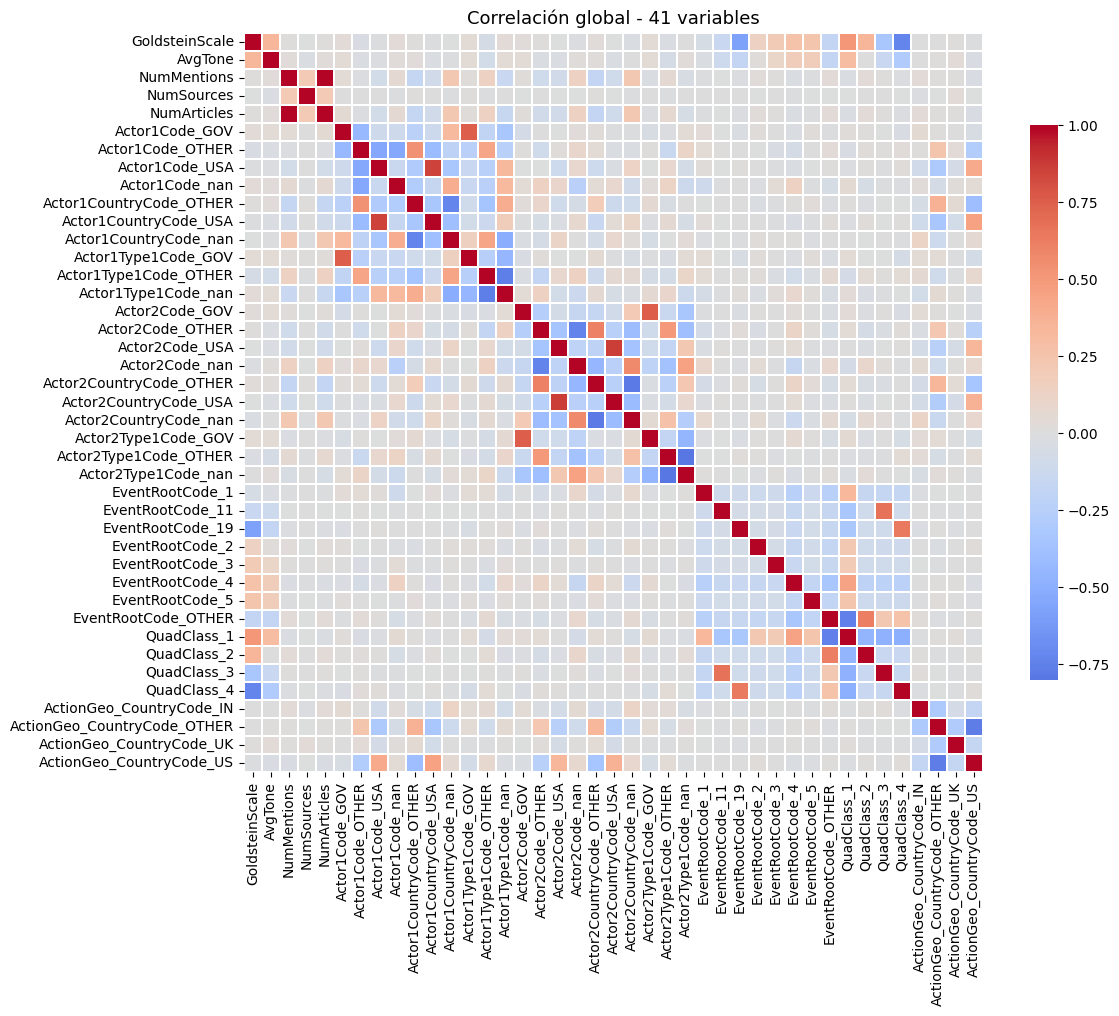

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_global = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_global, cmap="coolwarm", center=0, square=True,
            linewidths=0.2, cbar_kws={"shrink": 0.75})
plt.title(f"Correlación global - {X.shape[1]} variables", fontsize=13)
plt.tight_layout()
plt.show()

### Matriz de correlaciones por país

Un heatmap de todas las variables por cada país es ilegible. Reduzco a las 5 continuas + QuadClass (las 6 variables con interpretación directa), con `annot=True` para leer valores. También agrego un heatmap de diferencia `corr_pais - corr_global` para ver dónde cambia la estructura.

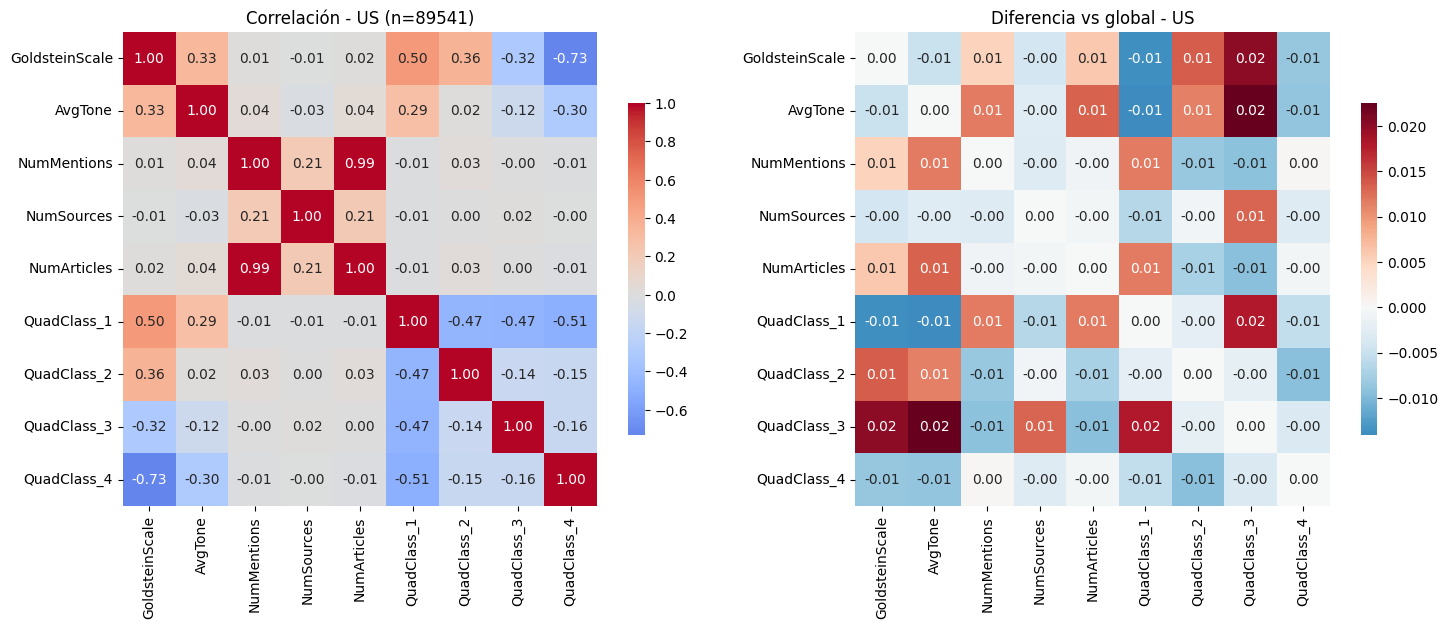

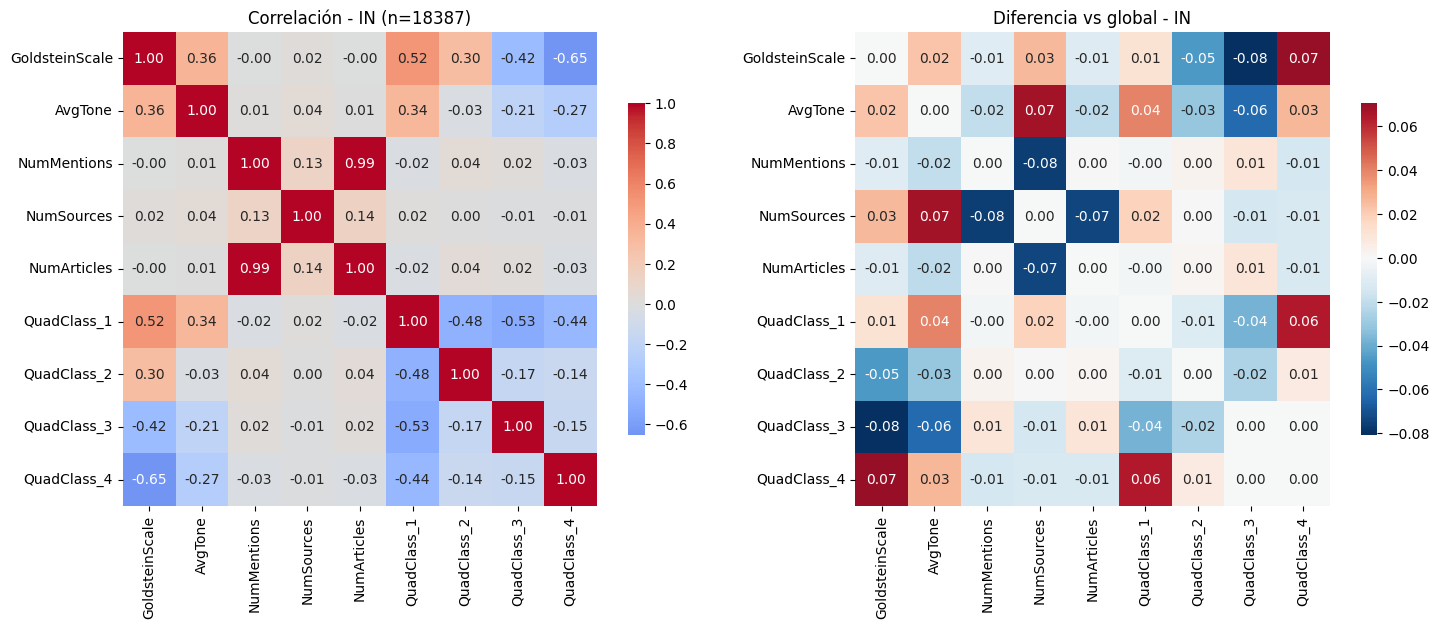

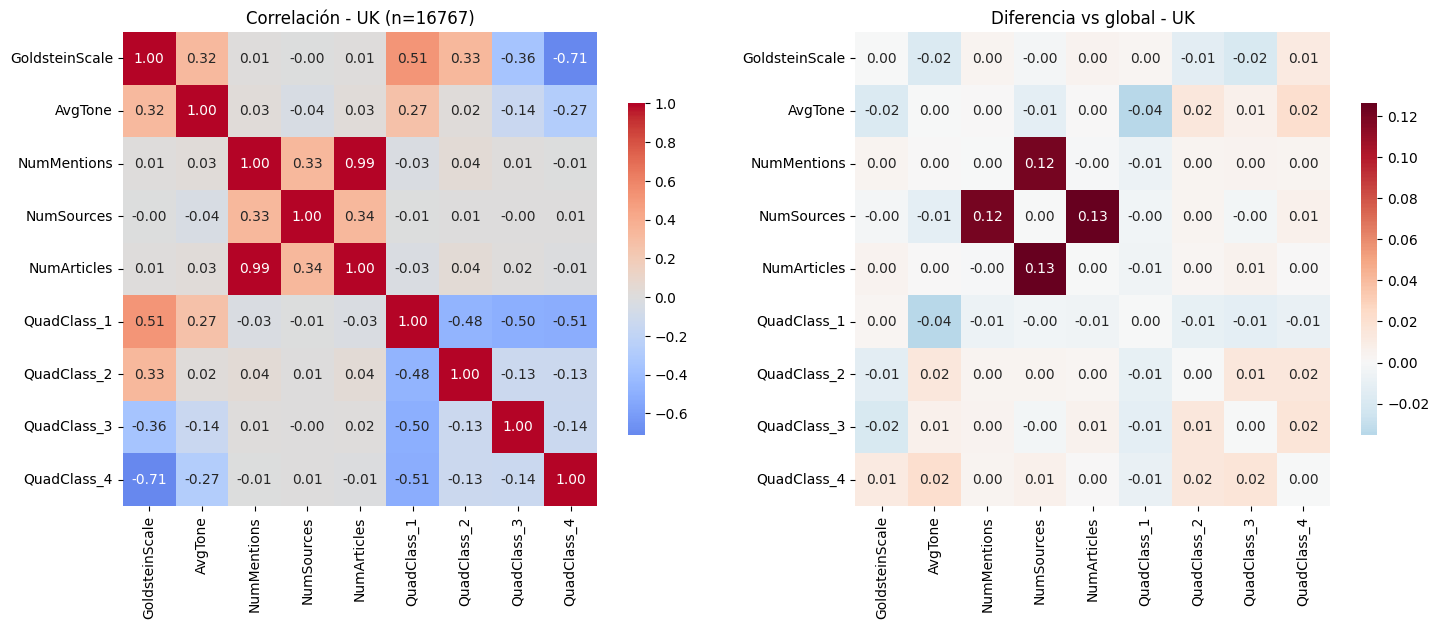

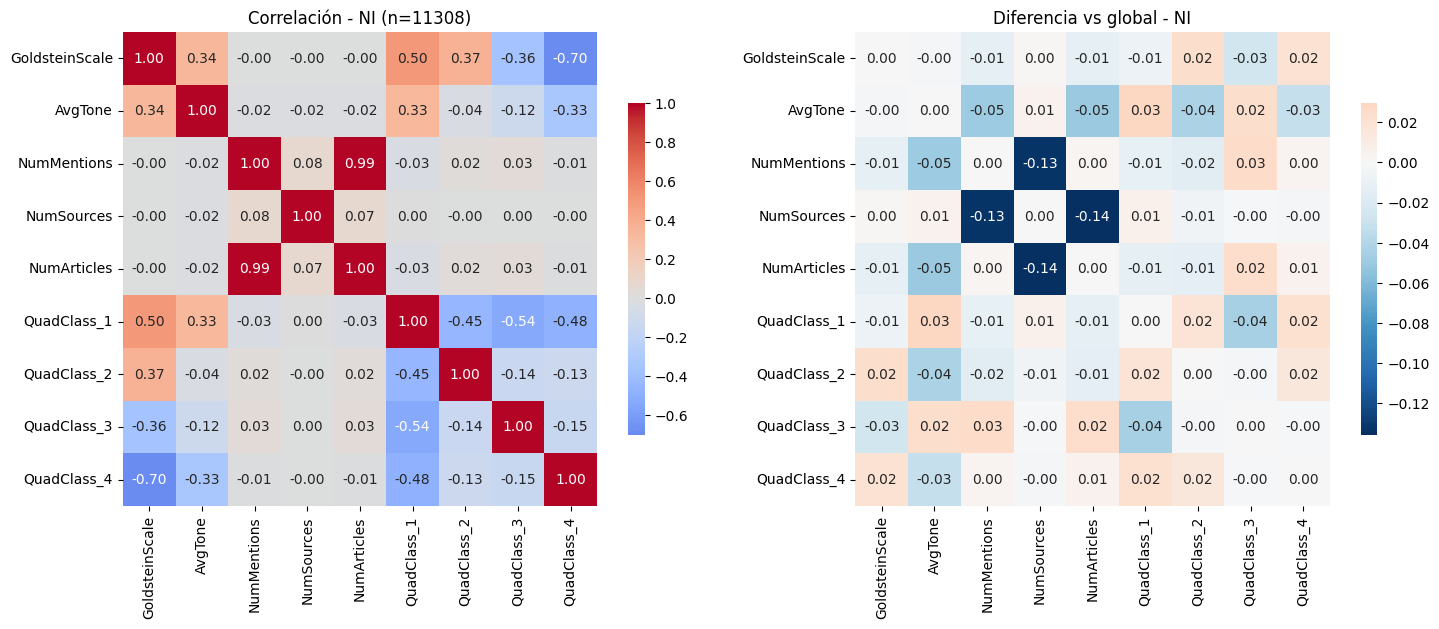

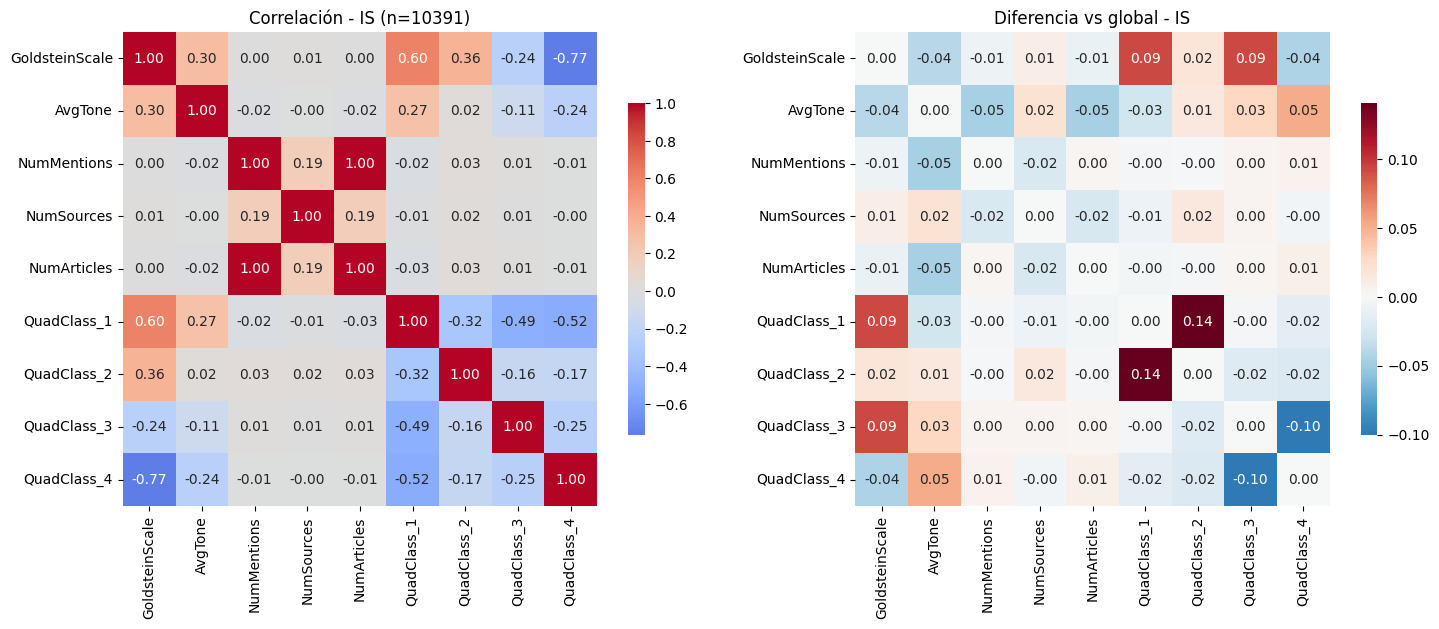

In [ ]:
vars_interp = cols_continuas + ["QuadClass_1", "QuadClass_2", "QuadClass_3", "QuadClass_4"]
vars_interp = [v for v in vars_interp if v in X.columns]

for pais in top_paises[:5]:
    mask = (pais_raw == pais).values
    if mask.sum() < 30:
        continue
    sub = X.loc[mask, vars_interp]
    corr_p = sub.corr()
    corr_diff = corr_p - corr_global.loc[vars_interp, vars_interp]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(corr_p, cmap="coolwarm", center=0, square=True,
                annot=True, fmt=".2f", ax=axes[0], cbar_kws={"shrink": 0.7})
    axes[0].set_title(f"Correlación - {pais} (n={mask.sum()})")
    sns.heatmap(corr_diff, cmap="RdBu_r", center=0, square=True,
                annot=True, fmt=".2f", ax=axes[1], cbar_kws={"shrink": 0.7})
    axes[1].set_title(f"Diferencia vs global - {pais}")
    plt.tight_layout()
    plt.show()

In [ ]:
# 1) Correlaciones clave por país
claves_corr = {
    "Mentions–Articles": ("NumMentions", "NumArticles"),
    "Mentions–Sources": ("NumMentions", "NumSources"),
    "Tone–Goldstein": ("AvgTone", "GoldsteinScale"),
}
filas = {"Global": {k: corr_global.loc[a, b] for k, (a, b) in claves_corr.items()}}
for pais in top_paises[:5]:
    mask = (pais_raw == pais).values
    if mask.sum() < 30:
        continue
    cp = X.loc[mask, vars_interp].corr()
    filas[f"{PAISES.get(pais, pais)} (n={mask.sum()})"] = {k: cp.loc[a, b] for k, (a, b) in claves_corr.items()}
display(pd.DataFrame(filas).T.round(3))

# 2) Mayores diferencias vs el global, por país
res = []
for pais in top_paises[:5]:
    mask = (pais_raw == pais).values
    if mask.sum() < 30:
        continue
    cp = X.loc[mask, vars_interp].corr()
    diff = cp - corr_global.loc[vars_interp, vars_interp]
    par = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool)).stack()
    for (a, b) in par.abs().sort_values(ascending=False).head(3).index:
        res.append({"pais": PAISES.get(pais, pais), "n": int(mask.sum()), "par": f"{a} – {b}",
                    "corr_pais": cp.loc[a, b], "corr_global": corr_global.loc[a, b],
                    "diferencia": diff.loc[a, b]})
display(pd.DataFrame(res).round(3))

,Mentions–Articles,Mentions–Sources,Tone–Goldstein
Global,0.992,0.208,0.338
EE.UU. (n=89541),0.991,0.205,0.332
India (n=18387),0.993,0.132,0.361
Reino Unido (n=16767),0.990,0.329,0.319
Nigeria (n=11308),0.994,0.075,0.335
Israel (n=10391),0.995,0.185,0.299


,pais,n,par,corr_pais,corr_global,diferencia
0,EE.UU.,89541,AvgTone – QuadClass_3,-0.121,-0.143,0.023
1,EE.UU.,89541,GoldsteinScale – QuadClass_3,-0.316,-0.336,0.020
2,EE.UU.,89541,QuadClass_1 – QuadClass_3,-0.473,-0.491,0.018
3,India,18387,GoldsteinScale – QuadClass_3,-0.417,-0.336,-0.081
4,India,18387,NumMentions – NumSources,0.132,0.208,-0.076
5,India,18387,NumSources – NumArticles,0.135,0.209,-0.074
6,Reino Unido,16767,NumSources – NumArticles,0.335,0.209,0.126
7,Reino Unido,16767,NumMentions – NumSources,0.329,0.208,0.121
8,Reino Unido,16767,AvgTone – QuadClass_1,0.266,0.301,-0.035
9,Nigeria,11308,NumSources – NumArticles,0.073,0.209,-0.136


### Lectura

- **Bloque de cobertura**: `NumMentions` y `NumArticles` son casi redundantes en todos los países (r ≈ [[rango de la tabla]]); `NumSources` se asocia débilmente con ambas (r ≈ [[rango]]).
- **Tono e impacto**: `AvgTone` y `GoldsteinScale` muestran correlación positiva moderada en todos los países (r entre [[mín]] y [[máx]]).
- **QuadClass**: sus cuatro dummies se correlacionan negativamente entre sí en todos los países, como corresponde a categorías excluyentes.
- **Diferencias por país**: el mapa `corr_pais − corr_global` muestra cambios mínimos. En EE.UU. (n = 89.541, cerca del 30% de la muestra) ninguna diferencia supera 0.02 en valor absoluto, es decir, su estructura de correlación es prácticamente idéntica a la global. [[Para los otros países: citar el par con mayor diferencia de la segunda tabla y su valor]]. Con muestras chicas (ver `n`), diferencias de esa magnitud pueden deberse a ruido muestral.

En conjunto, hay un esqueleto de correlación común a todos los países, con variaciones locales pequeñas.

# Actividad 3: Reducción de dimensionalidad

## Ajuste del ACP

Ajusto el ACP sobre la matriz escalada. Pido todas las componentes en este primer ajuste. La decisión de cuántas retener la tomo con tres criterios: codo del scree plot, umbral de varianza acumulada al 80%, y criterio de Kaiser (autovalores > 1).

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(matriz_escalada)

varianza_ind  = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza_ind)
autovalores   = pca.explained_variance_

print(f"Componentes ajustadas: {len(varianza_ind)}")
print(f"PC1 explica:  {varianza_ind[0]:.2%}")
print(f"PC2 explica:  {varianza_ind[1]:.2%}")
print(f"PC1+PC2:      {varianza_acum[1]:.2%}")
print(f"PC1..PC10:    {varianza_acum[9]:.2%}")

Componentes ajustadas: 41
PC1 explica:  9.50%
PC2 explica:  8.60%
PC1+PC2:      18.11%
PC1..PC10:    64.73%


## Análisis de varianza explicada

Grafico solo las primeras 30 componentes porque con 131 columnas el codo no se ve. Calculo tres criterios de retención:

1. **Codo**: cambio de pendiente en el scree plot.
2. **Varianza acumulada ≥ 80%**.
3. **Kaiser**: autovalores > 1.

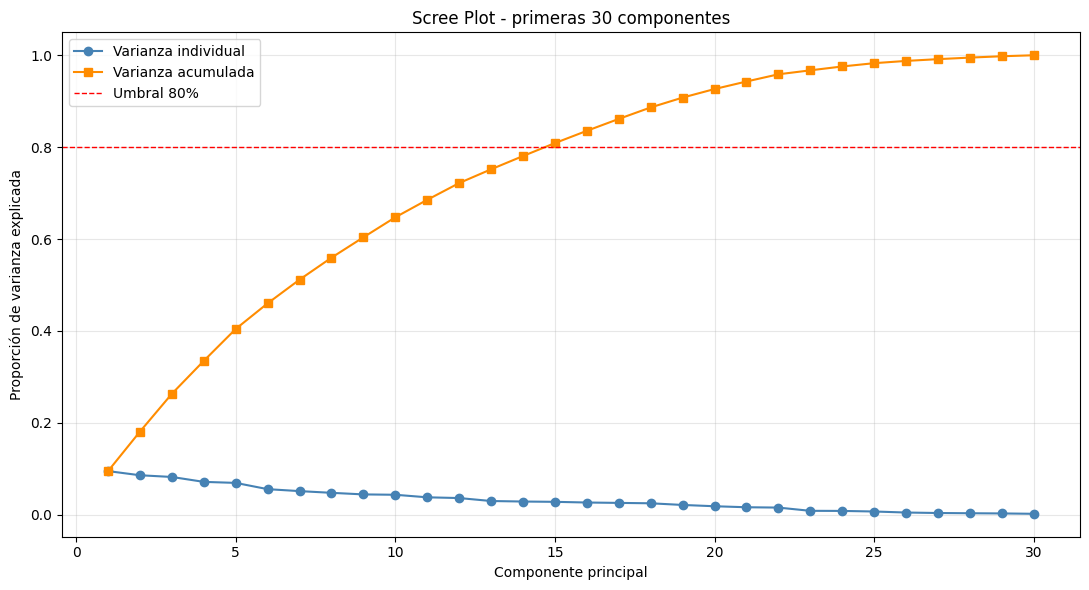

Componentes para ≥80% de varianza: 15  (acum = 80.87%)
Componentes con autovalor > 1 (Kaiser): 18


In [ ]:
N_VIEW = min(30, len(varianza_ind))

plt.figure(figsize=(11, 6))
plt.plot(range(1, N_VIEW+1), varianza_ind[:N_VIEW],
         marker="o", color="steelblue", label="Varianza individual")
plt.plot(range(1, N_VIEW+1), varianza_acum[:N_VIEW],
         marker="s", color="darkorange", label="Varianza acumulada")
plt.axhline(y=0.80, color="red", linestyle="--", linewidth=1, label="Umbral 80%")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.title(f"Scree Plot - primeras {N_VIEW} componentes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_acum   = int(np.argmax(varianza_acum >= 0.80) + 1)
n_kaiser = int((autovalores > 1).sum())

print(f"Componentes para ≥80% de varianza: {n_acum}  (acum = {varianza_acum[n_acum-1]:.2%})")
print(f"Componentes con autovalor > 1 (Kaiser): {n_kaiser}")

### Decisión

Evalúo los tres criterios:

- **Codo**: no hay un codo claro. La varianza individual baja de forma gradual y casi lineal (PC1 = 9.50%, PC2 = 8.60%, PC3 = 8.23%, PC4 = 7.16%…) hasta cerca de PC22, sin un quiebre marcado. Esto es esperable en una matriz con muchas dummies: cada bloque categórico aporta dimensiones casi independientes, por lo que ninguna componente domina. Es un hallazgo en sí: el ecosistema de eventos se comprime mal.
- **Varianza acumulada**: se necesitan **15 componentes** para superar el 80% (acumulado = 80.87%). Las primeras 10 explican el 64.73%.
- **Kaiser**: hay **18 componentes** con autovalor > 1.

**Decisión final: n_componentes = 15.**

Justificación:

1. Es el número que alcanza el umbral del 80% de varianza acumulada, criterio objetivo ante la ausencia de un codo definido.
2. Es menor que el criterio de Kaiser (18), lo que evita retener componentes con varianza marginal.
3. Es una cantidad manejable para interpretar y justifica la reducción: se pasa de 41 variables a 15 componentes conservando el 80.87% de la varianza.

La reducción es del 63% en dimensiones (41 → 15) con una pérdida del 19.13% de varianza.

In [ ]:
n_componentes = int(np.argmax(varianza_acum >= 0.80) + 1)
print(f"n_componentes seleccionado: {n_componentes}")
print(f"Varianza acumulada: {varianza_acum[n_componentes-1]:.2%}")

n_componentes seleccionado: 15
Varianza acumulada: 80.87%


## Interpretación de los loadings

Para cada una de las primeras `n_componentes` componentes, ordeno las variables por valor absoluto del loading y miro las 10-12 con mayor peso. Les asigno un nombre conceptual según qué variables dominan.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=matriz_datos.columns
)

for i in range(min(n_componentes, 6)):
    pc = f"PC{i+1}"
    top = loadings[pc].abs().sort_values(ascending=False).head(12)
    print(f"\n=== {pc} ({varianza_ind[i]:.2%}) - Top 12 ===")
    display(loadings.loc[top.index, pc].to_frame(name="loading"))


=== PC1 (9.50%) - Top 12 ===


,loading
Actor2CountryCode_OTHER,0.324935
Actor2Code_OTHER,0.314246
Actor1CountryCode_OTHER,0.288611
ActionGeo_CountryCode_US,-0.276980
ActionGeo_CountryCode_OTHER,0.270817
Actor2Code_nan,-0.267324
Actor2CountryCode_nan,-0.232311
QuadClass_1,0.225265
Actor1Type1Code_OTHER,-0.198916
Actor1Type1Code_nan,0.192692



=== PC2 (8.60%) - Top 12 ===


,loading
QuadClass_1,0.365420
GoldsteinScale,0.297434
Actor1Code_OTHER,-0.289141
QuadClass_4,-0.269008
ActionGeo_CountryCode_US,0.257717
EventRootCode_OTHER,-0.240377
Actor1Code_USA,0.238669
ActionGeo_CountryCode_OTHER,-0.235507
Actor1CountryCode_USA,0.232751
Actor1CountryCode_OTHER,-0.206240



=== PC3 (8.23%) - Top 12 ===


...

,loading
Actor2CountryCode_nan,0.447359
Actor2Code_USA,-0.397135
Actor2CountryCode_USA,-0.387883
Actor2Type1Code_nan,-0.239395
NumArticles,0.215652
NumMentions,0.215105
Actor2Code_nan,0.211935
Actor2CountryCode_OTHER,-0.209508
Actor2Code_GOV,0.205497
Actor2Type1Code_GOV,0.164708



=== PC5 (6.94%) - Top 12 ===


,loading
Actor1CountryCode_nan,0.343108
Actor2Code_OTHER,0.321162
Actor2Type1Code_OTHER,0.318592
Actor2Type1Code_nan,-0.307283
Actor2Code_nan,-0.274520
Actor1CountryCode_OTHER,-0.271706
Actor1Code_OTHER,-0.267086
Actor1Code_nan,0.262784
Actor1Code_GOV,0.246251
NumArticles,0.204308



=== PC6 (5.58%) - Top 12 ===


,loading
Actor1Code_GOV,0.330028
Actor1Type1Code_GOV,0.312442
Actor2Code_GOV,-0.304624
Actor2Type1Code_GOV,-0.293366
Actor2Type1Code_nan,0.283051
Actor1Code_OTHER,-0.245797
Actor2CountryCode_USA,-0.239448
Actor2Code_USA,-0.225027
Actor1Type1Code_OTHER,-0.216464
Actor2Code_nan,0.210395


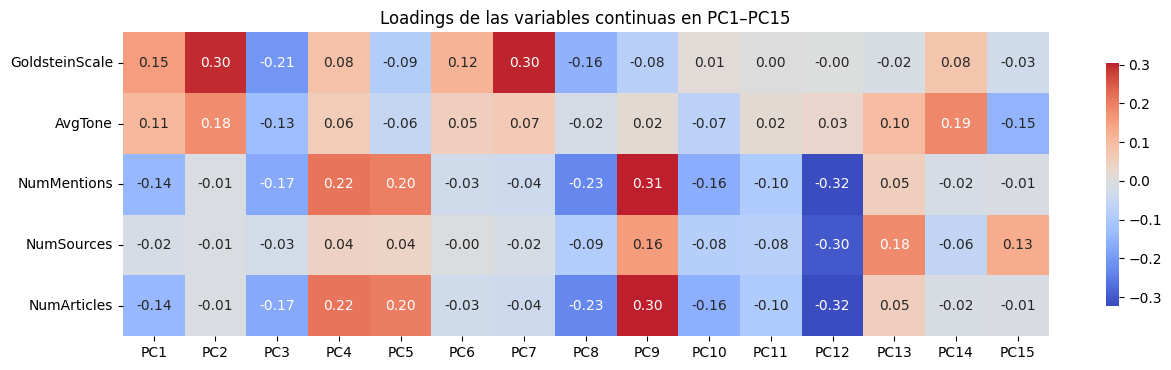

,PC donde más pesa
GoldsteinScale,PC7
AvgTone,PC14
NumMentions,PC12
NumSources,PC12
NumArticles,PC12


In [ ]:
# Peso de las variables continuas en las 15 componentes retenidas
cargas_cont = loadings.loc[cols_continuas, :f"PC{n_componentes}"]

plt.figure(figsize=(13, 3.8))
sns.heatmap(cargas_cont, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={"shrink": 0.8})
plt.title(f"Loadings de las variables continuas en PC1–PC{n_componentes}")
plt.tight_layout()
plt.show()

display(cargas_cont.abs().idxmax(axis=1).to_frame("PC donde más pesa"))

In [ ]:
for i in range(5):
    pc = f"PC{i+1}"
    top = loadings[pc].abs().sort_values(ascending=False).head(12)
    print(f"\n=== {pc} ({varianza_ind[i]:.2%}) ===")
    print(loadings.loc[top.index, pc].to_string())


=== PC1 (9.50%) ===
Actor2CountryCode_OTHER        0.324935
Actor2Code_OTHER               0.314246
Actor1CountryCode_OTHER        0.288611
ActionGeo_CountryCode_US      -0.276980
ActionGeo_CountryCode_OTHER    0.270817
Actor2Code_nan                -0.267324
Actor2CountryCode_nan         -0.232311
QuadClass_1                    0.225265
Actor1Type1Code_OTHER         -0.198916
Actor1Type1Code_nan            0.192692
Actor1CountryCode_nan         -0.177026
EventRootCode_OTHER           -0.174976

=== PC2 (8.60%) ===
QuadClass_1                    0.365420
GoldsteinScale                 0.297434
Actor1Code_OTHER              -0.289141
QuadClass_4                   -0.269008
ActionGeo_CountryCode_US       0.257717
EventRootCode_OTHER           -0.240377
Actor1Code_USA                 0.238669
ActionGeo_CountryCode_OTHER   -0.235507
Actor1CountryCode_USA          0.232751
Actor1CountryCode_OTHER       -0.206240
EventRootCode_19              -0.192730
EventRootCode_4                0.18593

### Nombres conceptuales de las componentes

Leo el top-12 de cada componente y asigno nombre. No uso nombres de convención: los escribo mirando las variables que realmente dominan.

**PC1 (9.50%) — "Evento internacional con actor 2 identificado vs. evento doméstico de EE.UU. sin actor 2"**

Dominan `Actor2CountryCode_OTHER` (+0.325), `Actor2Code_OTHER` (+0.314), `Actor1CountryCode_OTHER` (+0.289) y `ActionGeo_CountryCode_OTHER` (+0.271) en el polo positivo, contra `ActionGeo_CountryCode_US` (−0.277), `Actor2Code_nan` (−0.267) y `Actor2CountryCode_nan` (−0.232) en el negativo. `QuadClass_1` (cooperación verbal) carga +0.225. La componente separa eventos con actores y región fuera de las categorías frecuentes, y con un actor 2 identificado, de eventos localizados en EE.UU. que no tienen actor 2.

**PC2 (8.60%) — "Cooperación vs. conflicto"**

Es la componente más interpretable. Dominan `QuadClass_1` (+0.365), `GoldsteinScale` (+0.297) y `EventRootCode_4` (+0.186, consultar) en el polo positivo, contra `QuadClass_4` (−0.269, conflicto material) y `EventRootCode_19` (−0.193, combatir) en el negativo. También separa actores y regiones: `Actor1Code_USA` (+0.239) y `ActionGeo_CountryCode_US` (+0.258) cargan positivo, mientras que `Actor1Code_OTHER` (−0.289) y `ActionGeo_CountryCode_OTHER` (−0.236) cargan negativo. [[Agregar si corresponde: "AvgTone carga X.XX en PC2", con el valor de la celda de loadings. Si es bajo, escribir que el tono no es el eje principal de esta componente]].

**PC3 (8.23%) — "Estados Unidos como actor 1"**

Dominan `Actor1Code_USA` (+0.345), `Actor1Type1Code_nan` (+0.340) y `Actor1CountryCode_USA` (+0.314) en el polo positivo, contra `Actor1CountryCode_nan` (-0.275) y `Actor1Type1Code_OTHER` (-0.255) en el negativo. `QuadClass_4` (+0.202, conflicto material) también carga positivo. La componente aísla específicamente la presencia de EE.UU. como actor principal del evento, con cierta asociación a conflicto.

**PC4 (7.16%) — "Estados Unidos como actor 2 / ausencia de actor 2"**

Dominan `Actor2CountryCode_nan` (+0.447), `Actor2Code_nan` (+0.212) y `Actor2Code_GOV` (+0.205) en el positivo, contra `Actor2Code_USA` (-0.397) y `Actor2CountryCode_USA` (-0.388) en el negativo. NumMentions y NumArticles cargan levemente positivo (+0.215), lo que indica que los eventos sin actor 2 tienen algo más de cobertura. La componente contrasta eventos con EE.UU. como segundo actor frente a eventos sin segundo actor definido o con actor gubernamental.

**PC5 (6.94%) — "Actores gubernamentales vs. otros actores"**

Dominan `Actor1CountryCode_nan` (+0.343), `Actor1Code_nan` (+0.263) y `Actor1Code_GOV` (+0.246) en el positivo, contra `Actor1CountryCode_OTHER` (-0.272) y `Actor1Code_OTHER` (-0.267) en el negativo. También `Actor2Code_OTHER` (+0.321) y `Actor2Type1Code_OTHER` (+0.319) en positivo, con `Actor2Type1Code_nan` (-0.307) y `Actor2Code_nan` (-0.275) en negativo. NumMentions y NumArticles cargan +0.20, indicando cobertura ligeramente mayor. La componente separa eventos con actores gubernamentales / sin código identificado de eventos con actores catalogados como "OTHER".

Las restantes componentes (PC6 a PC15) explican proporciones menores y en conjunto completan el 80.87% de varianza acumulada. Retener 15 componentes responde al criterio de varianza acumulada ≥ 80%, no a la interpretabilidad individual de cada una.

## Biplot PC1 vs PC2

Proyecto las observaciones sobre las dos primeras componentes. Con la muestra completa el gráfico satura, así que uso 5.000 puntos aleatorios (semilla fija).

Escalo las flechas de loadings con un factor derivado de los datos, no con un `*4` arbitrario. Dibujo solo las 10 variables con mayor norma combinada en PC1-PC2 para no saturar.

Identifico outliers multivariantes por distancia euclídea al origen en el plano PC1-PC2 y los listo.

Proporción de eventos con ActionGeo = US en la muestra completa: 30.2%


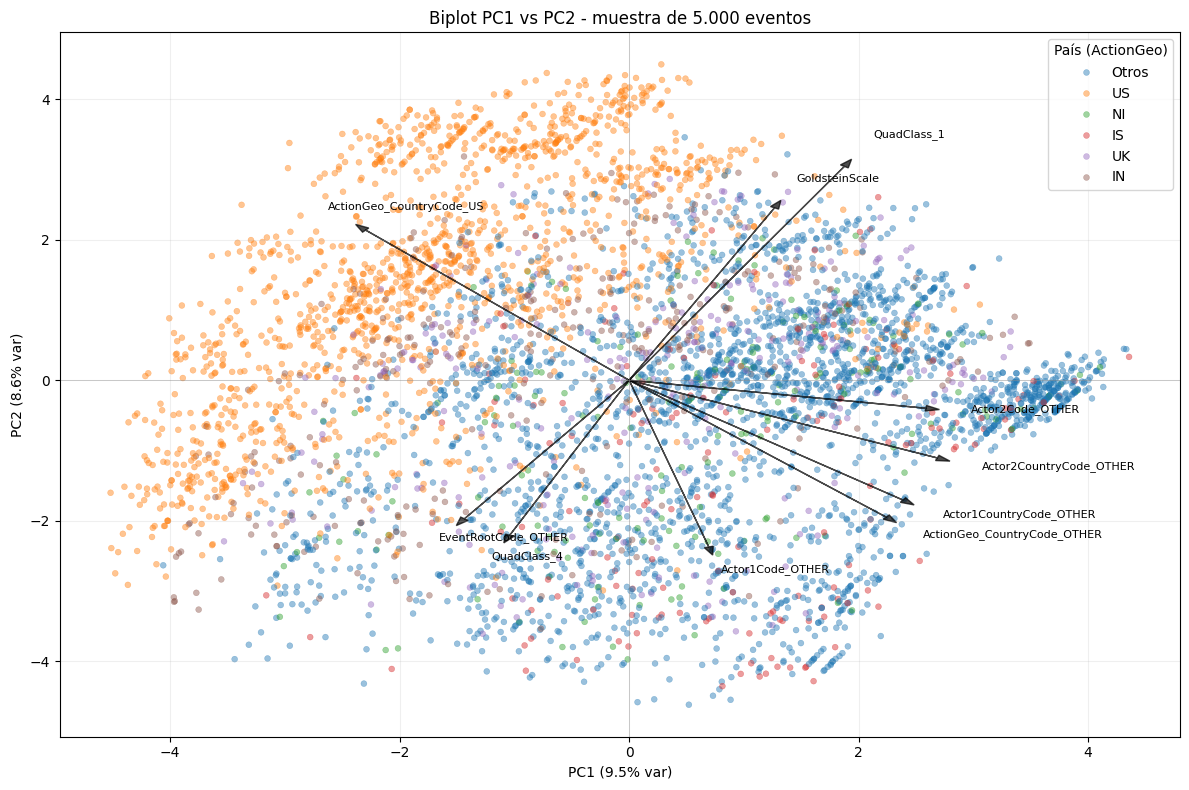

Top 10 eventos más alejados del origen en PC1-PC2 (NumMentions/Sources/Articles en escala log1p):


,GoldsteinScale,AvgTone,NumMentions,NumSources,NumArticles,EventRootCode,QuadClass,ActionGeo_CountryCode
255533,-9.5,-5.581395,4.394449,2.197225,4.394449,19,4,UK
165546,-10.0,-21.794872,2.397895,0.693147,2.397895,19,4,OTHER
31016,-10.0,-6.622517,4.394449,0.693147,4.394449,19,4,OTHER
198747,-10.0,-16.949153,2.397895,0.693147,2.397895,19,4,IN
71433,-9.0,-10.714286,3.218876,0.693147,3.218876,OTHER,4,US
182608,-9.5,-3.529412,3.433987,1.386294,3.433987,19,4,US
248463,-9.0,-18.539326,2.397895,0.693147,2.397895,OTHER,4,US
139994,-5.0,-7.505519,4.394449,2.197225,4.394449,OTHER,4,OTHER
58662,-10.0,-15.441176,2.397895,0.693147,2.397895,19,4,US
241260,-10.0,-3.485206,3.295837,1.386294,3.295837,19,4,US


Distribución de QuadClass en estos 10: {'4': 10}


In [ ]:
pca_2 = PCA(n_components=2)
componentes = pca_2.fit_transform(matriz_escalada)

np.random.seed(42)
idx = np.random.choice(len(componentes), size=5000, replace=False)
comp_sample = componentes[idx]

# Solo los 5 países más frecuentes; el resto como "Otros"
top5 = pais_raw.value_counts().head(5).index
pais_s = pais_raw.values[idx]
paises_sample = np.where(pd.Series(pais_s).isin(top5), pais_s, "Otros")
print(f"Proporción de eventos con ActionGeo = US en la muestra completa: {(pais_raw == 'US').mean():.1%}")

plt.figure(figsize=(12, 8))
sns.scatterplot(x=comp_sample[:, 0], y=comp_sample[:, 1], hue=paises_sample,
                alpha=0.45, s=18, palette="tab10", edgecolor=None)

normas = np.hypot(pca_2.components_[0], pca_2.components_[1])
top_vars = np.argsort(normas)[-10:]
escala = np.abs(comp_sample).max() * 0.8 / normas[top_vars].max()

for i in top_vars:
    x = pca_2.components_[0, i] * escala
    y = pca_2.components_[1, i] * escala
    plt.arrow(0, 0, x, y, color="black", alpha=0.7, head_width=0.08, length_includes_head=True)
    plt.text(x * 1.10, y * 1.10, matriz_datos.columns[i], fontsize=8, color="black")

plt.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
plt.axvline(0, color="grey", linewidth=0.5, alpha=0.5)
plt.xlabel(f"PC1 ({varianza_ind[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({varianza_ind[1]*100:.1f}% var)")
plt.title("Biplot PC1 vs PC2 - muestra de 5.000 eventos")
plt.legend(title="País (ActionGeo)", loc="best")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Outliers multivariantes en el plano PC1-PC2
d = np.hypot(componentes[:, 0], componentes[:, 1])
idx_out = np.argsort(d)[-10:][::-1]
print("Top 10 eventos más alejados del origen en PC1-PC2 (NumMentions/Sources/Articles en escala log1p):")
display(df_analitico.iloc[idx_out][cols_continuas + ["EventRootCode", "QuadClass", "ActionGeo_CountryCode"]])
print("Distribución de QuadClass en estos 10:", df_analitico.iloc[idx_out]["QuadClass"].value_counts().to_dict())

### Lectura

- **Agrupamientos**: el biplot muestra tres patrones.
  1. Los eventos con `ActionGeo = US` forman una nube densa en el cuadrante superior izquierdo (PC1−, PC2+). Representan ≈30% de la muestra (89.541 de 296.204 eventos), y la mayor parte del grupo se separa claramente del resto.
  2. Los eventos del grupo "Otros" (países fuera de los 5 más frecuentes) ocupan la mitad derecha del plano, con una concentración compacta alrededor de PC1 ≈ 3.5–4 y PC2 ≈ 0. Es el polo de eventos internacionales con actores y región fuera de las categorías frecuentes, que es el eje PC1 positivo.
  3. India, Reino Unido, Nigeria e Israel se mezclan entre sí y con "Otros" en la zona central, sin una separación clara por país. Esto es coherente con las distancias entre vectores de medias, que eran moderadas, salvo para EE.UU.
  
  Las bandas y filas de puntos que se ven en el gráfico son un efecto de las variables indicadoras (0/1), que generan valores discretos en la proyección.

- **Outliers**: los 10 eventos más alejados del origen en PC1–PC2 son **todos de `QuadClass = 4` (conflicto material)**. Siete de los diez son `EventRootCode = 19` (combatir) y los otros tres pertenecen a la categoría agrupada `OTHER`. Todos tienen `GoldsteinScale` muy negativo (entre −5 y −10) y `AvgTone` muy negativo (entre −3.5 y −21.8). Su cobertura es moderada: `NumMentions` en escala log1p va de 2.4 a 4.4, es decir, entre unas 10 y 80 menciones, y `NumSources` de 1 a 8 fuentes aproximadamente. Cinco ocurren en EE.UU., uno en Reino Unido, uno en India y tres en el grupo "Otros". En conjunto, son **eventos de violencia extrema con tono muy negativo, no eventos de cobertura excepcional**. Se alejan del centro porque combinan Goldstein muy negativo, `QuadClass_4` y tono muy negativo, lo que los ubica en el polo de conflicto de PC2 (valores muy bajos).

- **Dirección de las flechas**:
  - `ActionGeo_CountryCode_US` apunta hacia arriba-izquierda (PC1−, PC2+), coherente con sus loadings (−0.277 en PC1 y +0.258 en PC2) y con la ubicación de la nube de EE.UU.
  - `QuadClass_1` y `GoldsteinScale` apuntan juntas hacia arriba-derecha, lo que confirma que PC2 es el eje cooperación vs. conflicto.
  - `Actor2Code_OTHER`, `Actor2CountryCode_OTHER`, `Actor1CountryCode_OTHER` y `ActionGeo_CountryCode_OTHER` apuntan hacia la derecha (PC1+), en dirección opuesta a `ActionGeo_CountryCode_US`.
  - `QuadClass_4`, `EventRootCode_OTHER` y `Actor1Code_OTHER` apuntan hacia abajo, en sentido opuesto a `QuadClass_1` y `GoldsteinScale`: es el polo de conflicto de PC2, donde están los outliers.

El biplot es consistente con los loadings: PC1 contrasta eventos domésticos de EE.UU. con eventos internacionales de actores menos frecuentes, y PC2 separa cooperación de conflicto. Los outliers multivariantes corresponden al extremo de conflicto de PC2.

## Síntesis final

### Perfil multivariante de eventos
El vector de medias global (en escala estandarizada) caracteriza al evento promedio. Los vectores por país muestran diferencias moderadas: Canadá y Reino Unido son los más cercanos al promedio; EE.UU. se aparta por su composición de actores; Israel e Irán por tono y Goldstein más negativos; y los eventos sin país asignado por una cobertura mucho mayor.

### Topología de cobertura mediática
Los pares más similares son Reino Unido–Canadá (0.361), Australia–Reino Unido (0.456) e Israel–Irán (0.581). Los más disímiles involucran a los eventos sin país y a EE.UU. (Israel–Sin país 2.986, Sin país–Irán 2.946, EE.UU.–Israel 2.779). Las diferencias de tono y Goldstein son de décimas de desvío estándar.

### Estructura de correlación
`NumMentions` y `NumArticles` son casi redundantes (r ≈ 0.99); `NumSources` se asocia débilmente (r ≈ 0.21). `AvgTone` y `GoldsteinScale` se asocian de forma moderada (r ≈ 0.33), y `GoldsteinScale` se asocia fuertemente con `QuadClass_4` (≈ −0.73). La estructura es prácticamente idéntica entre países (en EE.UU., |Δ| ≤ 0.02).

### Compresión del ecosistema de noticias
No hay un codo claro en el scree plot. Se necesitan **15 componentes** para explicar el 80.87% de la varianza (Kaiser sugiere 18), lo que indica una compresión modesta (41 → 15). PC1 = "evento internacional con actor 2 vs. evento doméstico de EE.UU. sin actor 2", PC2 = "cooperación vs. conflicto", PC3 = "EE.UU. como actor 1", PC4 = "EE.UU. como actor 2 / ausencia de actor 2", PC5 = "actores gubernamentales vs. otros". [[Agregar en qué PC aparecen cobertura y tono, según el heatmap de loadings]].

### Limitaciones
- La reducción de cardinalidad al 5% elimina categorías de cola larga: en `ActionGeo_CountryCode` solo quedan US, IN y UK. Para el análisis por país se usaron los 10 países más frecuentes, que tienen tamaños muy desiguales (ver `n_eventos`).
- El muestreo del 10% por archivo introduce variabilidad; la muestra final tiene 296.204 eventos.
- Escalar las dummies amplifica las categorías raras, al darles el mismo peso que a las continuas.
- Los conteos de cobertura se transformaron con log1p antes de escalar.
- La interpretación de componentes es provisional y requiere validación con ejemplos concretos de eventos.

## Declaración de uso de inteligencia artificial

- **Gemini 2.5 Pro**: asesoramiento en la reimplementación del Data Warehouse del TP2 y en la redacción inicial de la estructura del notebook.
- **Claude Sonnet 5.5**: revisión crítica del notebook, detección de errores metodológicos (variables no categóricas contaminando el ACP, dummies de país contaminando las distancias, interpretaciones de loadings y gráficos que no coincidían con los resultados) y propuesta de correcciones de código y de redacción.
- El análisis, la interpretación de los resultados y las decisiones metodológicas son de elaboración propia.